<a href="https://colab.research.google.com/github/Mohitjain1708/mlproject/blob/main/Customerchurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


In [ ]:
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')

# Display the first few rows
print(df.head())

# Drop unnecessary columns
df.drop(['customerID'], axis=1, inplace=True)

# Convert TotalCharges to numeric (handling any non-numeric values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode categorical variables
le = LabelEncoder()
for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

# Split into features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

<ipython-input-4-9f745c914a16>:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:
# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predictions
log_preds = log_model.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))
print("Classification Report:\n", classification_report(y_test, log_preds))


Logistic Regression Accuracy: 0.815471965933286
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("Classification Report:\n", classification_report(y_test, rf_preds))


Random Forest Accuracy: 0.7963094393186657
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



In [ ]:
# Support Vector Machine
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Predictions
svm_preds = svm_model.predict(X_test)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, svm_preds))
print("Classification Report:\n", classification_report(y_test, svm_preds))


SVM Accuracy: 0.8069552874378992
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.92      0.87      1036
           1       0.68      0.50      0.58       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [ ]:
# Accuracy scores for all models
model_results = {
    'Logistic Regression': accuracy_score(y_test, log_preds),
    'Random Forest': accuracy_score(y_test, rf_preds),
    'SVM': accuracy_score(y_test, svm_preds),
}

# Display model results
print("Model Accuracy Comparison:")
print(pd.DataFrame(model_results, index=['Accuracy']).T)


Model Accuracy Comparison:
                     Accuracy
Logistic Regression  0.815472
Random Forest        0.796309
SVM                  0.806955


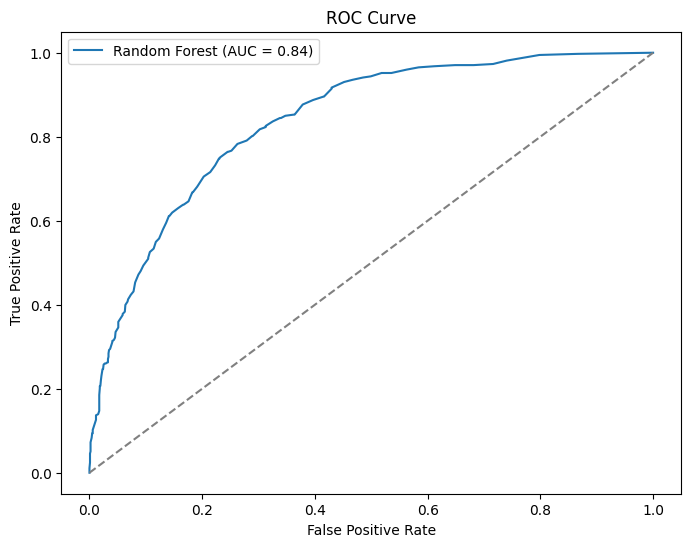

In [ ]:
# ROC Curve for Random Forest (example)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


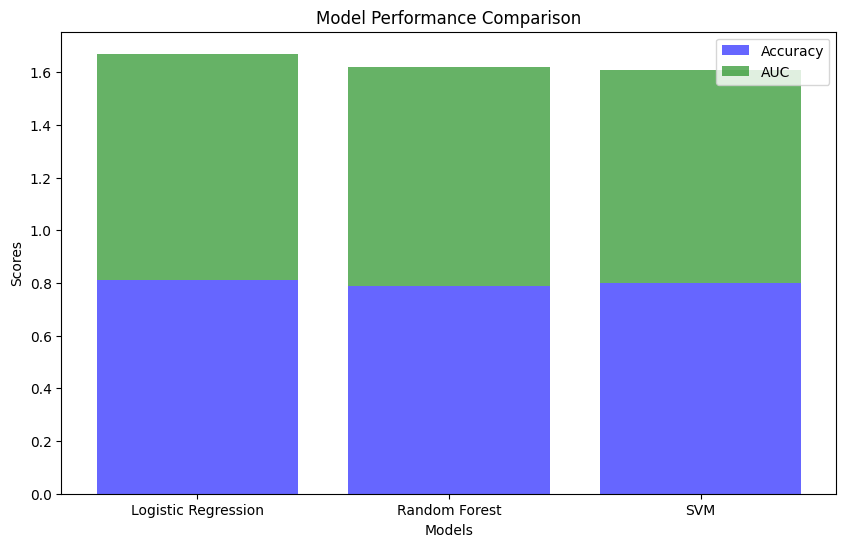

In [ ]:
# Example: Bar chart for model performance
import matplotlib.pyplot as plt

# Data for plotting
models = ['Logistic Regression', 'Random Forest', 'SVM']
accuracy = [0.81, 0.79, 0.80]
auc = [0.86, 0.83, 0.81]

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(models, accuracy, color='blue', alpha=0.6, label='Accuracy')
plt.bar(models, auc, color='green', alpha=0.6, label='AUC', bottom=accuracy)
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.legend()
plt.show()


Logistic Regression Accuracy: 0.8155
Logistic Regression AUC: 0.8614

Random Forest Accuracy: 0.7949
Random Forest AUC: 0.8348

SVM Accuracy: 0.8070
SVM AUC: 0.8132



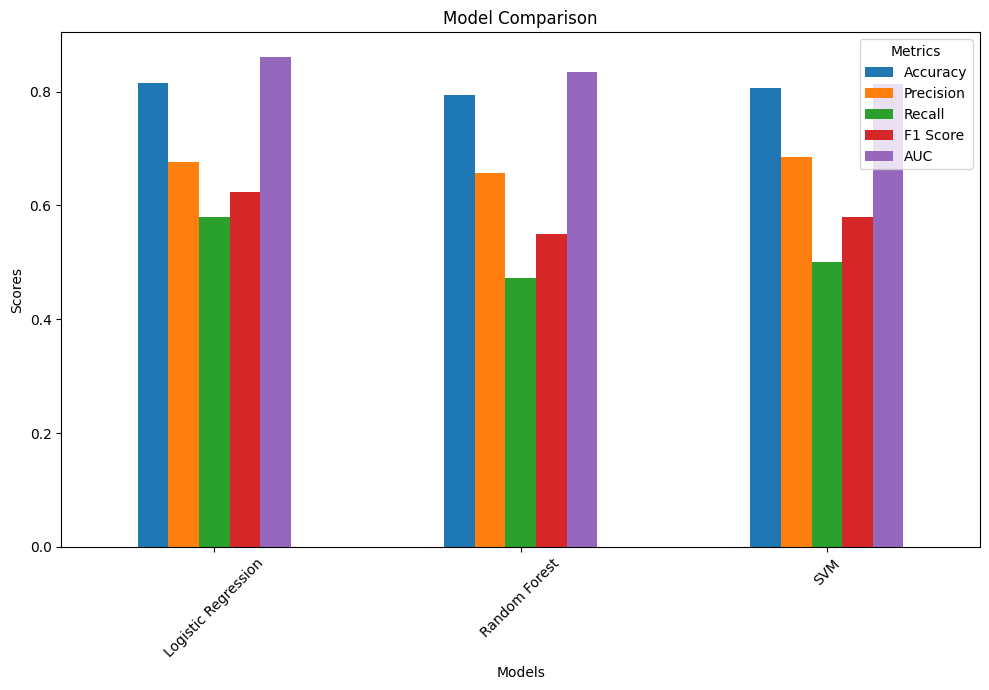

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')

# Preprocessing steps
df = df.drop(['customerID'], axis=1)  # Drop 'customerID' column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encoding categorical variables
le = LabelEncoder()
for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

# Split into features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the models
lr_model = LogisticRegression()
rf_model = RandomForestClassifier()
svm_model = SVC(probability=True)

# Fit the models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

# Get metrics for each model
def get_metrics(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except AttributeError:
        y_prob = None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    return accuracy, precision, recall, f1, auc

# Store metrics for each model
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

metrics = {}

# Print accuracy and AUC before plotting
for name, model in models.items():
    accuracy, precision, recall, f1, auc = get_metrics(model, X_train, X_test, y_train, y_test)
    metrics[name] = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1 Score": f1, "AUC": auc}
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(f"{name} AUC: {auc:.4f}\n")

# Convert metrics into DataFrame
metrics_df = pd.DataFrame(metrics).T

# Plotting the comparison bar chart
metrics_df.plot(kind='bar', figsize=(10, 7))
plt.title('Model Comparison')
plt.ylabel('Scores')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.legend(title='Metrics', loc='best')
plt.tight_layout()
plt.show()


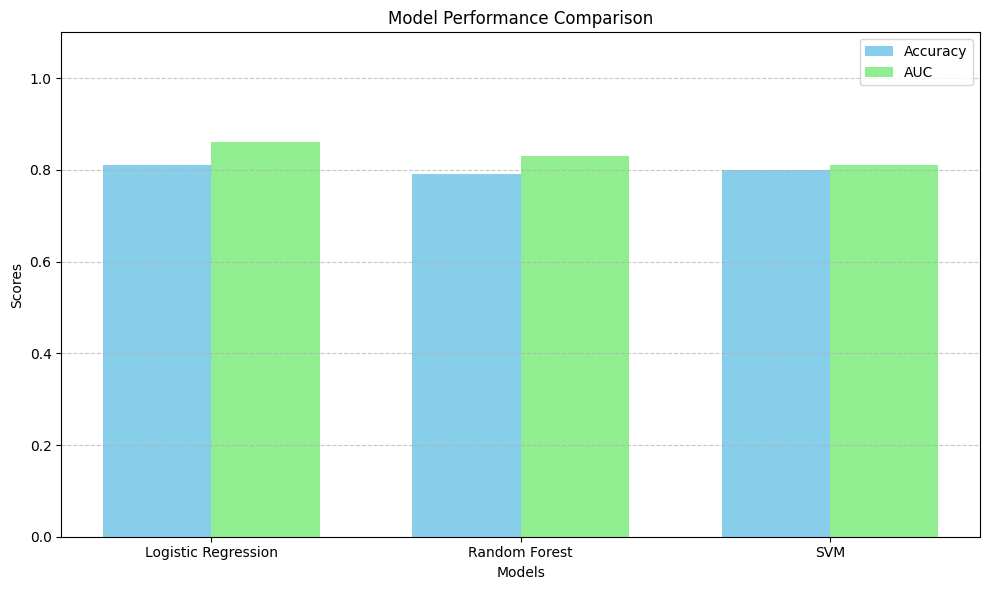

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
models = ['Logistic Regression', 'Random Forest', 'SVM']
accuracy = [0.81, 0.79, 0.80]
auc = [0.86, 0.83, 0.81]

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, accuracy, width, label='Accuracy', color='skyblue')
plt.bar(x + width/2, auc, width, label='AUC', color='lightgreen')

# Labels and titles
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(x, models)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
